# Задание 1. RNN, LSTM и GRU

Используя код из лекции, попробуйте обучить RNN с размерностью скрытого состояния `hidden_size`=2 на следующих периодичных данных и визуализируйте результат.

In [51]:
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [52]:
input_size = 1
hidden_size = 2

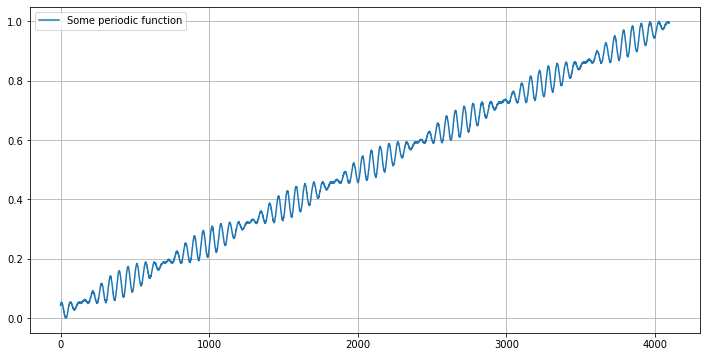

In [53]:
training_data = []
for i in range(4096):
    training_data.append(math.sin(i / 10) +
                         math.cos((i) / 9) +
                         i / 100 +
                         (random.random() - 0.5) / 5)
training_data = np.array(training_data).reshape((len(training_data), 1))
# Min - Max normalization
training_data -= training_data.min()
training_data = training_data / training_data.max()
# plotting
plt.figure(figsize=(12, 6))
plt.plot(training_data, label='Some periodic function')
plt.legend()
plt.grid()
plt.show()

In [54]:
# create data "ensemble"
def sliding_windows(data, seq_length):
    X = []
    Y = []

    for i in range(len(data)-seq_length):
        _X = data[i:(i+seq_length)] # picking several sequential observations
        _Y = data[i+seq_length] # picking the subsequent observation
        X.append(_X)
        Y.append(_Y)

    return torch.Tensor(np.array(X)), torch.Tensor(np.array(Y))
    
# set length of the ensemble; accuracy of the predictions and 
# speed perfomance almost always depend on it size
seq_length = 8 # compare 2 and 32
X, Y = sliding_windows(training_data, seq_length)
print("Example of the obtained data:\n")
print("Data corresponding to the first X:")
print(X[0])
print("Data corresponding to the first Y:")
print(Y[0])

Example of the obtained data:

Data corresponding to the first X:
tensor([[0.0423],
        [0.0419],
        [0.0452],
        [0.0468],
        [0.0507],
        [0.0515],
        [0.0533],
        [0.0499]])
Data corresponding to the first Y:
tensor([0.0515])


In [55]:
train_size = int(len(Y) * 0.8)

X_train = X[:train_size]
Y_train = Y[:train_size]

X_test = X[train_size:]
Y_test = Y[train_size:]

print("Train data:")
print("X shape:", X_train.shape)
print("Y shape:", Y_train.shape)

print("\nTest data:")
print("X shape:", X_test.shape)
print("Y shape:", Y_test.shape)

Train data:
X shape: torch.Size([3270, 8, 1])
Y shape: torch.Size([3270, 1])

Test data:
X shape: torch.Size([818, 8, 1])
Y shape: torch.Size([818, 1])


In [56]:
class AirTrafficPredictor(nn.Module):

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first = True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h = self.rnn(x) 
        y = self.fc(h)
        return y, h

In [57]:
def time_series_train(model, num_epochs = 2000, learning_rate = 0.01):
  
  criterion = torch.nn.MSELoss() # mean-squared error for regression
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  # Train the model
  for epoch in range(num_epochs):
      Y_pred, h = model(X_train) # we don't use h there, but we can!
      optimizer.zero_grad()
      
      # obtain the loss
      loss = criterion(Y_pred[0], Y_train) # for shape compatibility
      loss.backward()
      
      optimizer.step()
      with torch.no_grad():
          Y_pred = model(X_test)
          testloss = criterion(Y_pred[0],Y_test)
      if epoch % 100 == 0:
          print(f"Epoch: {epoch},".ljust(15), "loss: %1.5f" % (loss.item()), "loss: %1.5f" % (testloss.item()))

print("Simple RNN training process with MSE loss:")
start = time.time()
rnn = AirTrafficPredictor(input_size, hidden_size)
time_series_train(rnn)

print(int(((time.time() - start) * 1000)) / 1000, 'sec')

Simple RNN training process with MSE loss:
Epoch: 0,       loss: 0.16711 loss: 0.00525


/usr/local/lib/python3.7/dist-packages/torch/nn/modules/loss.py:529: UserWarning: Using a target size (torch.Size([818, 1])) that is different to the input size (torch.Size([1, 818, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch: 100,     loss: 0.00004 loss: 0.00054
Epoch: 200,     loss: 0.00003 loss: 0.00079
Epoch: 300,     loss: 0.00003 loss: 0.00077
Epoch: 400,     loss: 0.00003 loss: 0.00074
Epoch: 500,     loss: 0.00003 loss: 0.00071
Epoch: 600,     loss: 0.00003 loss: 0.00068
Epoch: 700,     loss: 0.00002 loss: 0.00065
Epoch: 800,     loss: 0.00002 loss: 0.00062
Epoch: 900,     loss: 0.00002 loss: 0.00058
Epoch: 1000,    loss: 0.00002 loss: 0.00055
Epoch: 1100,    loss: 0.00002 loss: 0.00052
Epoch: 1200,    loss: 0.00002 loss: 0.00049
Epoch: 1300,    loss: 0.00002 loss: 0.00046
Epoch: 1400,    loss: 0.00002 loss: 0.00043
Epoch: 1500,    loss: 0.00002 loss: 0.00040
Epoch: 1600,    loss: 0.00002 loss: 0.00038
Epoch: 1700,    loss: 0.00002 loss: 0.00035
Epoch: 1800,    loss: 0.00001 loss: 0.00033
Epoch: 1900,    loss: 0.00001 loss: 0.00031
17.883 sec


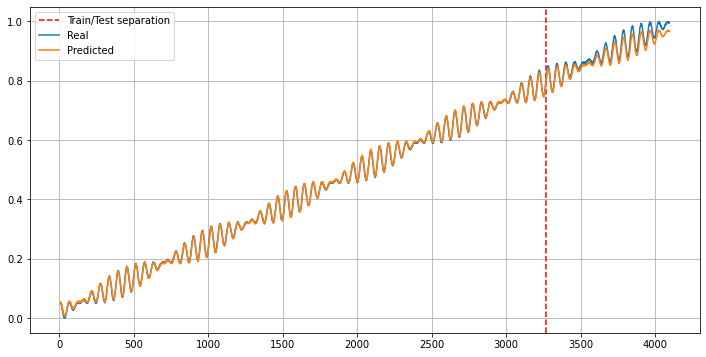

In [58]:
def time_series_plot(train_predict):
  data_predict = train_predict.data
  Y_data_plot = Y.data

  # Denormalize
  data_predict = data_predict[0] * (training_data.max() - training_data.min()) + training_data.min()
  Y_data_plot = Y_data_plot * (training_data.max() - training_data.min()) + training_data.min()

  # Ploitting
  plt.figure(figsize=(12, 6))
  plt.axvline(x=train_size, c='r', linestyle='--')
  # shifting the curve as first y-value not correspond first value overall
  plt.plot(seq_length + np.arange(Y_data_plot.shape[0]), Y_data_plot)
  plt.plot(seq_length + np.arange(Y_data_plot.shape[0]), data_predict)
  
  plt.legend(['Train/Test separation', 'Real', 'Predicted'])
  plt.grid(True)
  plt.show()

rnn.eval()
train_predict, h = rnn(X)
time_series_plot(train_predict)

Теперь обучите на этих же данных LSTM с 2 скрытыми слоями и визуализируйте результат.

In [59]:
class LSTMAirTrafficPredictor(nn.Module):

    def __init__(self, input_size, hidden_size):
        # hidden_size == number of neurons 
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first = True)
        self.fc = nn.Linear(hidden_size, 1) # Predict only one value

    def forward(self, x):
        out, (h,c) = self.lstm(x) 
        y = self.fc(h)
        return y

lstm =  LSTMAirTrafficPredictor(input_size, hidden_size)
input = torch.randn((108,8,1)) 
out = lstm(input)
print(out.shape)

torch.Size([1, 108, 1])


In [60]:
start = time.time()
lstm.train()

print("LSTM training process with MSE loss:")

num_epochs = 2000
learning_rate = 0.01

criterion = torch.nn.MSELoss() # mean-squared error for regression
optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate)

 # Train the model
for epoch in range(num_epochs):
    Y_pred = lstm(X_train) 
    optimizer.zero_grad()
    #print(outputs.shape)
    loss = criterion(Y_pred, Y_train.unsqueeze(0))
    loss.backward()
    
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch: {epoch},".ljust(15), "loss: %1.5f" % (loss.item()))

print(int(((time.time() - start) * 1000)) / 1000, 'sec')

LSTM training process with MSE loss:
Epoch: 0,       loss: 0.18681
Epoch: 100,     loss: 0.03195
Epoch: 200,     loss: 0.00008
Epoch: 300,     loss: 0.00007
Epoch: 400,     loss: 0.00006
Epoch: 500,     loss: 0.00005
Epoch: 600,     loss: 0.00005
Epoch: 700,     loss: 0.00004
Epoch: 800,     loss: 0.00004
Epoch: 900,     loss: 0.00003
Epoch: 1000,    loss: 0.00003
Epoch: 1100,    loss: 0.00002
Epoch: 1200,    loss: 0.00002
Epoch: 1300,    loss: 0.00002
Epoch: 1400,    loss: 0.00002
Epoch: 1500,    loss: 0.00001
Epoch: 1600,    loss: 0.00001
Epoch: 1700,    loss: 0.00001
Epoch: 1800,    loss: 0.00001
Epoch: 1900,    loss: 0.00001
24.211 sec


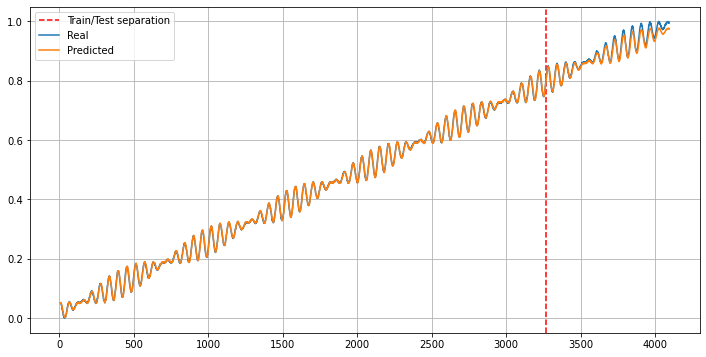

In [61]:
lstm.eval()
train_predict = lstm(X)
labels_to_display = [i for i in range(training_data.shape[0]) if i % 12 == 0]
time_series_plot(train_predict)

Произведите аналогичные действия с GRU моделью.

In [62]:
class GRU_Predictor(nn.Module):

    def __init__(self, input_size, hidden_size):
        # hidden_size == number of neurons 
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, batch_first = True)
        self.fc = nn.Linear(hidden_size, 1) # Predict only one value

    def forward(self, x):
        out, h = self.gru(x) 
        y = self.fc(h)
        return y

gru =  GRU_Predictor(input_size, hidden_size)

In [63]:
start = time.time()
gru.train()

print("GRU training process with MSE loss:")

num_epochs = 2000
learning_rate = 0.01

criterion = torch.nn.MSELoss() # mean-squared error for regression
optimizer = torch.optim.Adam(gru.parameters(), lr=learning_rate)

 # Train the model
for epoch in range(num_epochs):
    h0 = torch.randn(1, 8, 1)
    Y_pred = gru(X_train) 
    #print(Y_pred.size(), Y_train.unsqueeze(0).size())
    optimizer.zero_grad()
    #print(outputs.shape)
    loss = criterion(Y_pred, Y_train.unsqueeze(0))
    loss.backward()
    
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch: {epoch},".ljust(15), "loss: %1.5f" % (loss.item()))
print(int(((time.time() - start) * 1000)) / 1000, 'sec')

GRU training process with MSE loss:
Epoch: 0,       loss: 0.14159
Epoch: 100,     loss: 0.00027
Epoch: 200,     loss: 0.00017
Epoch: 300,     loss: 0.00014
Epoch: 400,     loss: 0.00011
Epoch: 500,     loss: 0.00009
Epoch: 600,     loss: 0.00008
Epoch: 700,     loss: 0.00007
Epoch: 800,     loss: 0.00006
Epoch: 900,     loss: 0.00005
Epoch: 1000,    loss: 0.00005
Epoch: 1100,    loss: 0.00004
Epoch: 1200,    loss: 0.00004
Epoch: 1300,    loss: 0.00004
Epoch: 1400,    loss: 0.00003
Epoch: 1500,    loss: 0.00003
Epoch: 1600,    loss: 0.00003
Epoch: 1700,    loss: 0.00003
Epoch: 1800,    loss: 0.00003
Epoch: 1900,    loss: 0.00002
18.322 sec


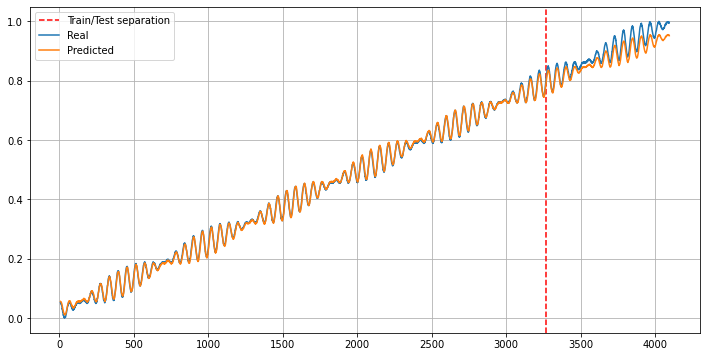

In [64]:
gru.eval()
output= gru(X)
time_series_plot(output)



Сравните результаты и скорость работы RNN, LSTM и GRU. 

В конкретно этом примере LSTM оказалось наиболее точной (совсем чуть чуть). 
По времени более долгой оказалась LSTM оказалась наиболее долгой в обучении. 

# Задание 2. The Wolf of Wall Street

Продолжение предыдущего задания с реальными данными. Попробуем написать сеть для прогнозирования цены акций.

Обычно, данные по ценам акций состоят из стандартных полей:
* `Open` - Цена открытия (цена в момент открытия торгов)
* `Close` - Цена закрытия
* `High` - Максимальная цена в течение торгового дня
* `Low` - Минимальная цена в течение дня
* `Volume` - Объём совершённых сделок (количество акций)

Скачайте исторические данные цены акций Google (или любой компании на ваш выбор) с сайта [finance.yahoo.com](https://finance.yahoo.com/quote/GOOG/history?p=GOOG) в формате csv во вкладка Historical Data.

* С интервалом в 5 лет или больше
* Частота данных: ежедневно

Выберите те поля, которые считаете нужными для нейронной сети. Если хотите, закодируйте месяцы периодичной функцией.

По одному или нескольким (рекомендую по нескольким) полям обучите на выбор RNN, LSTM, GRU предсказывать одно или несколько полей на неделю или месяц вперёд. (Например цену закрытия торгов)


In [65]:
import gdown
import math
import random

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd

In [66]:
dataset = pd.read_csv('GOOG.csv')#я брал от 8 мая 2005 года до 8 мая 2022 года, последняя дата на сайте 6 мая 2022 года
dataset.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2005-05-09,113.574295,113.823364,112.294090,112.587990,112.587990,11115107
1,2005-05-10,112.314018,113.474670,111.940422,113.474670,113.474670,12739171
2,2005-05-11,114.057487,115.556862,113.539429,115.213150,115.213150,23043651
3,2005-05-12,114.974052,115.681396,113.673920,113.932953,113.932953,17963480
4,2005-05-13,114.162094,115.113525,113.235565,114.191978,114.191978,14886590


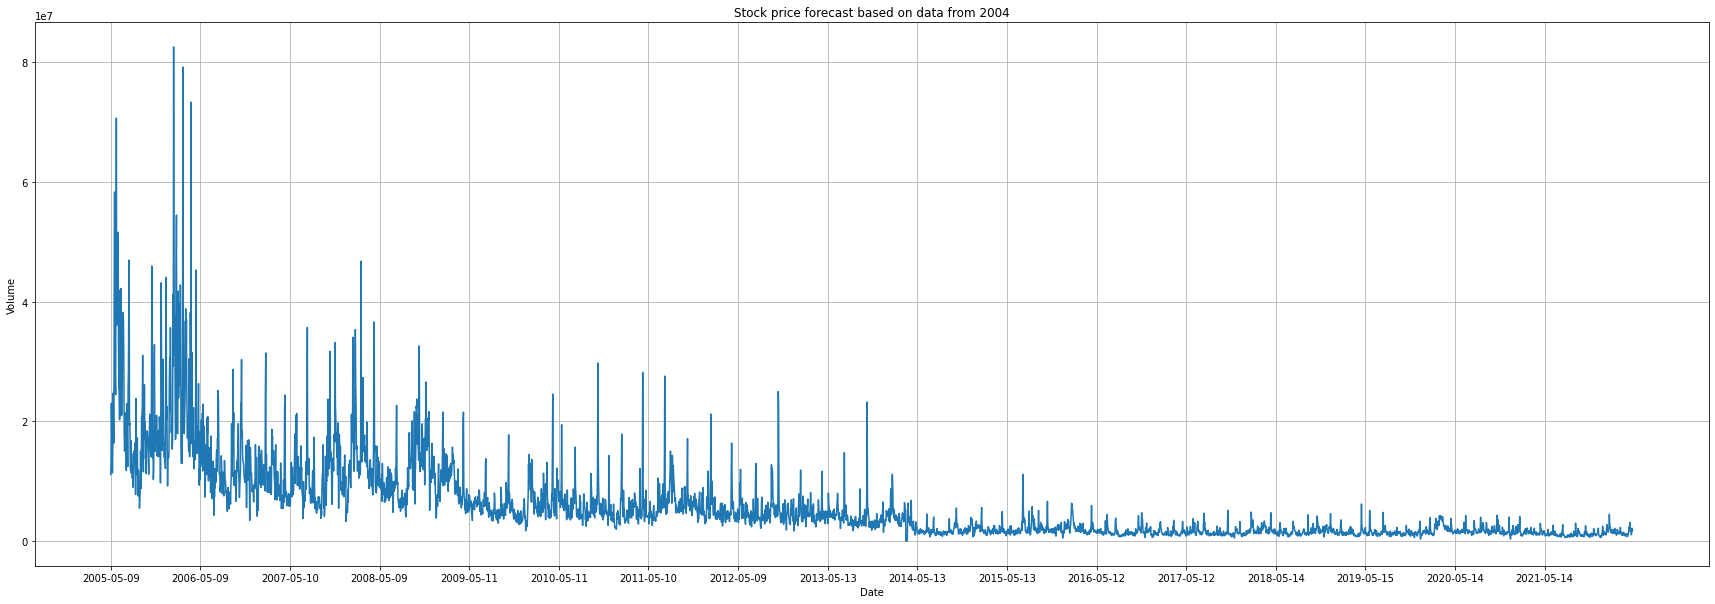

In [67]:
training_data = dataset.iloc[:,6:7].values 

plt.figure(figsize=(30, 10))

plt.plot(training_data, label = 'Date')

plt.title("Stock price forecast based on data from 2004")
plt.ylabel("Volume")
plt.xlabel("Date")

labels_to_display = [i for i in range(training_data.shape[0]) if i % 252 == 0 ] 
plt.xticks(labels_to_display, dataset['Date'][labels_to_display])

plt.grid()
plt.show()

In [68]:
# Min - Max normalization
td_min = training_data.min()
td_max = training_data.max()
print('Initial statistics:')
print('Minimum value:', repr(td_min).rjust(5))
print('Maximum value:', repr(td_max).rjust(5))

training_data = (training_data - td_min) / (td_max - td_min)
print('\nResulting statistics:')
print('Minimum value:', repr(training_data.min()).rjust(5))
print('Maximum value:', repr(training_data.max()).rjust(5))

Initial statistics:
Minimum value:  7922
Maximum value: 82541631

Resulting statistics:
Minimum value:   0.0
Maximum value:   1.0


In [69]:
def sliding_windows(data, seq_length):
    X = []
    Y = []

    for i in range(len(data)-seq_length):
        _X = data[i:(i+seq_length)]
        _Y = data[i+seq_length]
        X.append(_X)
        Y.append(_Y)

    return torch.Tensor(np.array(X)), torch.Tensor(np.array(Y))
    
seq_length = 21 #(дней в месяце в среднем)
X, Y = sliding_windows(training_data, seq_length)
print("Example of the obtained data:\n")
print("Data corresponding to the first X:")
print(X[0])
print("Data corresponding to the first Y:")
print(Y[0])

Example of the obtained data:

Data corresponding to the first X:
tensor([[0.1346],
        [0.1543],
        [0.2791],
        [0.2176],
        [0.1803],
        [0.1381],
        [0.1898],
        [0.2994],
        [0.2362],
        [0.1985],
        [0.5201],
        [0.7063],
        [0.4391],
        [0.3294],
        [0.2963],
        [0.5408],
        [0.8559],
        [0.4371],
        [0.4568],
        [0.5478],
        [0.5915]])
Data corresponding to the first Y:
tensor([0.6250])


In [70]:
train_size = int(len(Y) * 0.9)#предсказываем чуть больше чем на год

X_train = X[:train_size]
Y_train = Y[:train_size]

X_test = X[train_size:]
Y_test = Y[train_size:]

print("Train data:")
print("X shape:", X_train.shape)
print("Y shape:", Y_train.shape)

print("\nTest data:")
print("X shape:", X_test.shape)
print("Y shape:", Y_test.shape)

Train data:
X shape: torch.Size([3833, 21, 1])
Y shape: torch.Size([3833, 1])

Test data:
X shape: torch.Size([426, 21, 1])
Y shape: torch.Size([426, 1])


In [71]:
class LSTMAirTrafficPredictor(nn.Module):

    def __init__(self, input_size, hidden_size):
        # hidden_size == number of neurons 
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first = True)
        self.fc = nn.Linear(hidden_size, 1) # Predict only one value

    def forward(self, x):
        out, (h,c) = self.lstm(x) 
        y = self.fc(h)
        return y

lstm =  LSTMAirTrafficPredictor(input_size = 1, hidden_size = 2)
input = torch.randn((108,8,1)) 
out = lstm(input)
print(out.shape)

torch.Size([1, 108, 1])


In [72]:
lstm.train()

print("LSTM training process with MSE loss:")

num_epochs = 3000
learning_rate = 0.01

criterion = torch.nn.MSELoss() # mean-squared error for regression
optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate)

 # Train the model
for epoch in range(num_epochs):
    Y_pred = lstm(X_train) 
    optimizer.zero_grad()
    #print(outputs.shape)
    loss = criterion(Y_pred, Y_train.unsqueeze(0))
    loss.backward()
    
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch: {epoch},".ljust(15), "loss: %1.5f" % (loss.item()))

LSTM training process with MSE loss:
Epoch: 0,       loss: 0.18774
Epoch: 200,     loss: 0.00509
Epoch: 400,     loss: 0.00270
Epoch: 600,     loss: 0.00182
Epoch: 800,     loss: 0.00181
Epoch: 1000,    loss: 0.00181
Epoch: 1200,    loss: 0.00181
Epoch: 1400,    loss: 0.00181
Epoch: 1600,    loss: 0.00181
Epoch: 1800,    loss: 0.00180
Epoch: 2000,    loss: 0.00180
Epoch: 2200,    loss: 0.00179
Epoch: 2400,    loss: 0.00178
Epoch: 2600,    loss: 0.00176
Epoch: 2800,    loss: 0.00172


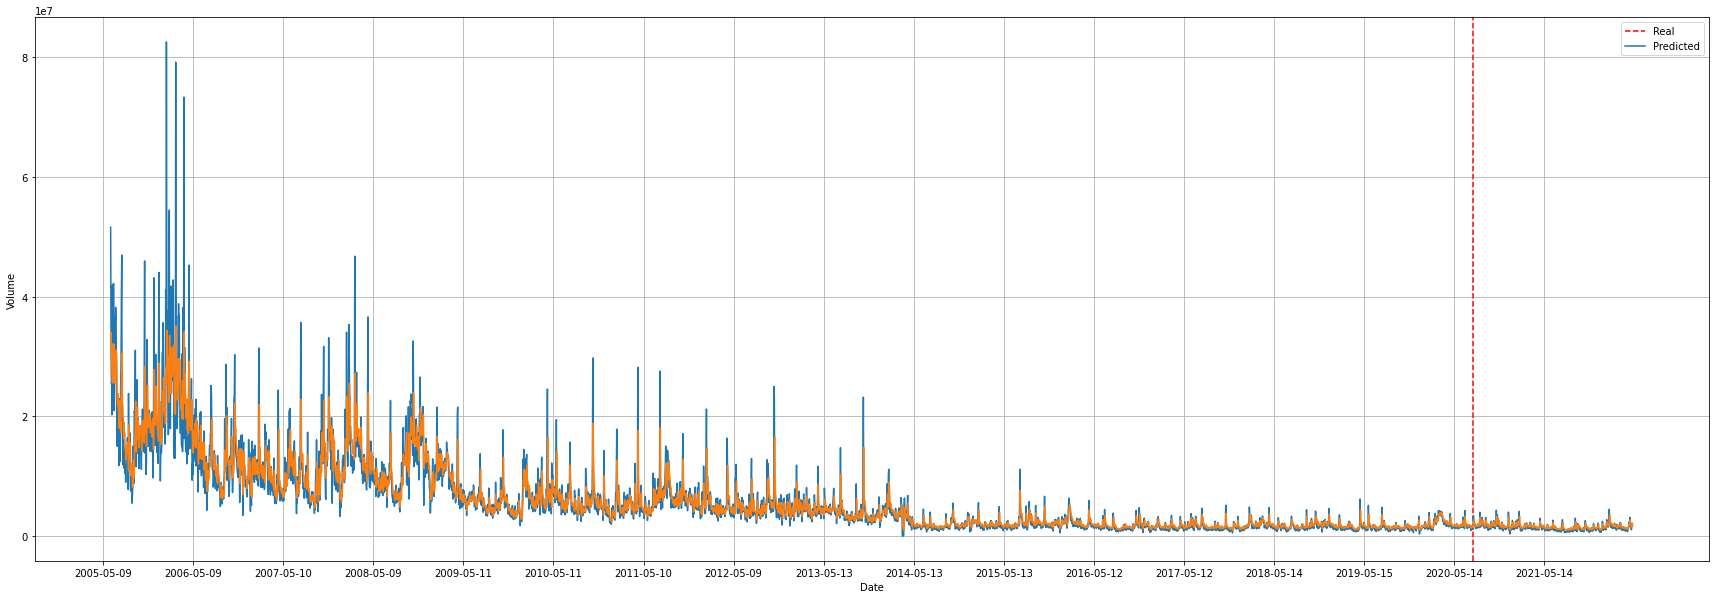

In [73]:
def time_series_plot(train_predict):
  data_predict = train_predict.data
  Y_data_plot = Y.data

  # Denormalize
  data_predict = data_predict[0] * (td_max- td_min) + td_min
  Y_data_plot = Y_data_plot * (td_max - td_min) + td_min

  # Ploitting
  plt.figure(figsize=(30, 10))
  plt.axvline(x=train_size, c='r', linestyle='--')
  # shifting the curve as first y-value not correspond first value overall
  plt.plot(seq_length + np.arange(Y_data_plot.shape[0]), Y_data_plot)
  plt.plot(seq_length + np.arange(Y_data_plot.shape[0]), data_predict)
  
  plt.legend(['Real', 'Predicted'])
  plt.ylabel("Volume")
  plt.xlabel("Date")

  labels_to_display = [i for i in range(training_data.shape[0]) if i % 252 == 0 ] 
  plt.xticks(labels_to_display, dataset['Date'][labels_to_display])
  plt.grid(True)
  plt.show()

lstm.eval()
train_predict = lstm(X)
time_series_plot(train_predict)

Вообще похо получилось даже описать, надо ставить сильно больше эпох, на 10к получается значительно лучше. Предсказать я бы сказал получилось, но хотелось бы еще лучше... Но и всеже это объем сделок, а не стоимость и мне кажется это сложнее предсказать чисто интуитивно.


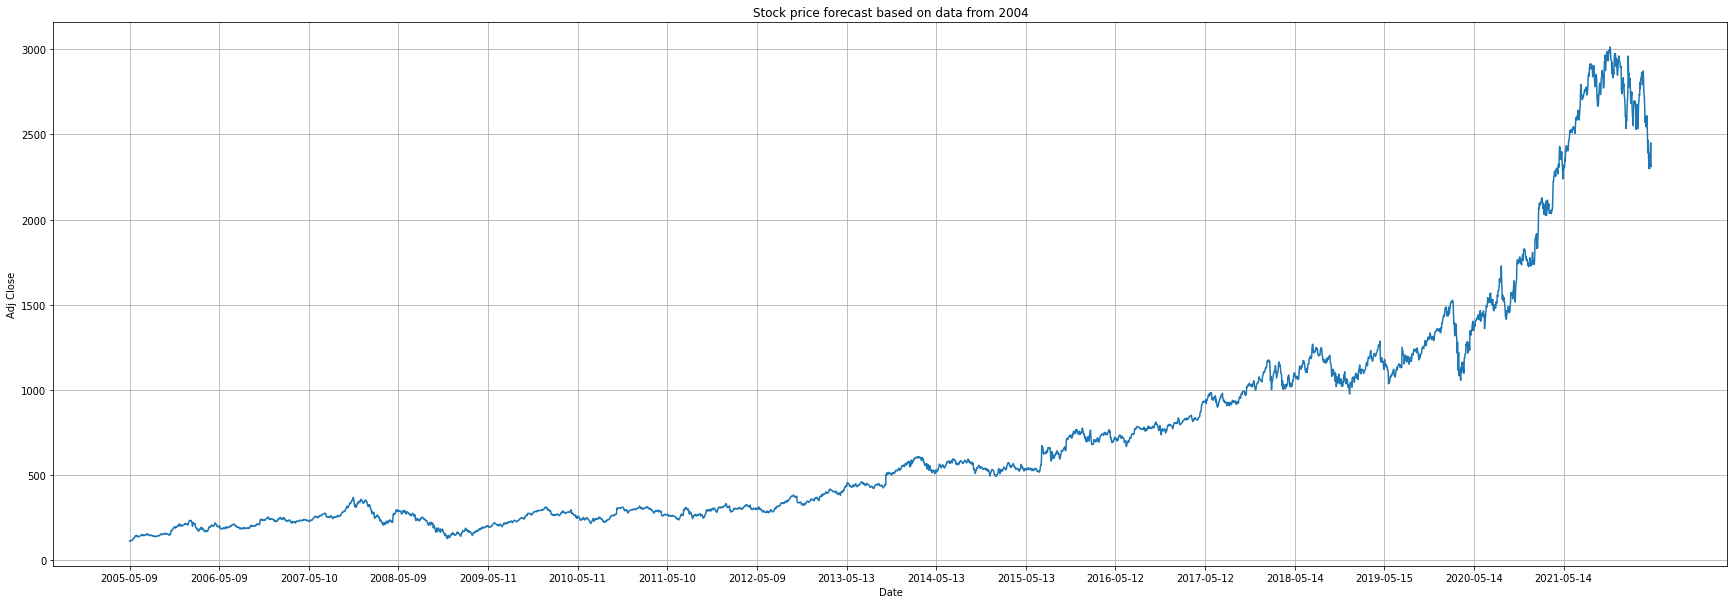

In [74]:
training_data = dataset.iloc[:,5:6].values 

plt.figure(figsize=(30, 10))

plt.plot(training_data, label = 'Date')

plt.title("Stock price forecast based on data from 2004")
plt.ylabel("Adj Close")
plt.xlabel("Date")

labels_to_display = [i for i in range(training_data.shape[0]) if i % 252 == 0 ] 
plt.xticks(labels_to_display, dataset['Date'][labels_to_display])

plt.grid()
plt.show()

In [75]:
# Min - Max normalization
td_min = training_data.min()
td_max = training_data.max()
print('Initial statistics:')
print('Minimum value:', repr(td_min).rjust(5))
print('Maximum value:', repr(td_max).rjust(5))

training_data = (training_data - td_min) / (td_max - td_min)
print('\nResulting statistics:')
print('Minimum value:', repr(training_data.min()).rjust(5))
print('Maximum value:', repr(training_data.max()).rjust(5))

Initial statistics:
Minimum value: 112.58799
Maximum value: 3014.179932

Resulting statistics:
Minimum value:   0.0
Maximum value:   1.0


In [76]:
def sliding_windows(data, seq_length):
    X = []
    Y = []

    for i in range(len(data)-seq_length):
        _X = data[i:(i+seq_length)] # picking several sequential observations
        _Y = data[i+seq_length] # picking the subsequent observation
        X.append(_X)
        Y.append(_Y)

    return torch.Tensor(np.array(X)), torch.Tensor(np.array(Y))
    
# set length of the ensemble; accuracy of the predictions and 
# speed perfomance almost always depend on it size
seq_length = 21 # compare 2 and 32
X, Y = sliding_windows(training_data, seq_length)
print("Example of the obtained data:\n")
print("Data corresponding to the first X:")
print(X[0])
print("Data corresponding to the first Y:")
print(Y[0])

Example of the obtained data:

Data corresponding to the first X:
tensor([[0.0000],
        [0.0003],
        [0.0009],
        [0.0005],
        [0.0006],
        [0.0009],
        [0.0012],
        [0.0023],
        [0.0023],
        [0.0027],
        [0.0051],
        [0.0051],
        [0.0060],
        [0.0057],
        [0.0069],
        [0.0088],
        [0.0106],
        [0.0106],
        [0.0093],
        [0.0111],
        [0.0115]])
Data corresponding to the first Y:
tensor([0.0092])


In [77]:
train_size = int(len(Y) * 0.9)#предсказываем чуть больше чем на год вперед

X_train = X[:train_size]
Y_train = Y[:train_size]

X_test = X[train_size:]
Y_test = Y[train_size:]

print("Train data:")
print("X shape:", X_train.shape)
print("Y shape:", Y_train.shape)

print("\nTest data:")
print("X shape:", X_test.shape)
print("Y shape:", Y_test.shape)

Train data:
X shape: torch.Size([3833, 21, 1])
Y shape: torch.Size([3833, 1])

Test data:
X shape: torch.Size([426, 21, 1])
Y shape: torch.Size([426, 1])


In [78]:
class LSTMAirTrafficPredictor(nn.Module):

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first = True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h,c) = self.lstm(x) 
        y = self.fc(h)
        return y

lstm =  LSTMAirTrafficPredictor(input_size = 1, hidden_size = 2)
input = torch.randn((108,8,1)) 
out = lstm(input)
print(out.shape)

torch.Size([1, 108, 1])


In [79]:
lstm.train()

print("LSTM training process with MSE loss:")

num_epochs = 3000
learning_rate = 0.01

criterion = torch.nn.MSELoss() 
optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate)

 # Train the model
for epoch in range(num_epochs):
    Y_pred = lstm(X_train) 
    optimizer.zero_grad()
    #print(outputs.shape)
    loss = criterion(Y_pred, Y_train.unsqueeze(0))
    loss.backward()
    
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch: {epoch},".ljust(15), "loss: %1.5f" % (loss.item()))

LSTM training process with MSE loss:
Epoch: 0,       loss: 0.28176
Epoch: 200,     loss: 0.00026
Epoch: 400,     loss: 0.00014
Epoch: 600,     loss: 0.00010
Epoch: 800,     loss: 0.00007
Epoch: 1000,    loss: 0.00006
Epoch: 1200,    loss: 0.00005
Epoch: 1400,    loss: 0.00004
Epoch: 1600,    loss: 0.00004
Epoch: 1800,    loss: 0.00003
Epoch: 2000,    loss: 0.00003
Epoch: 2200,    loss: 0.00003
Epoch: 2400,    loss: 0.00003
Epoch: 2600,    loss: 0.00002
Epoch: 2800,    loss: 0.00002


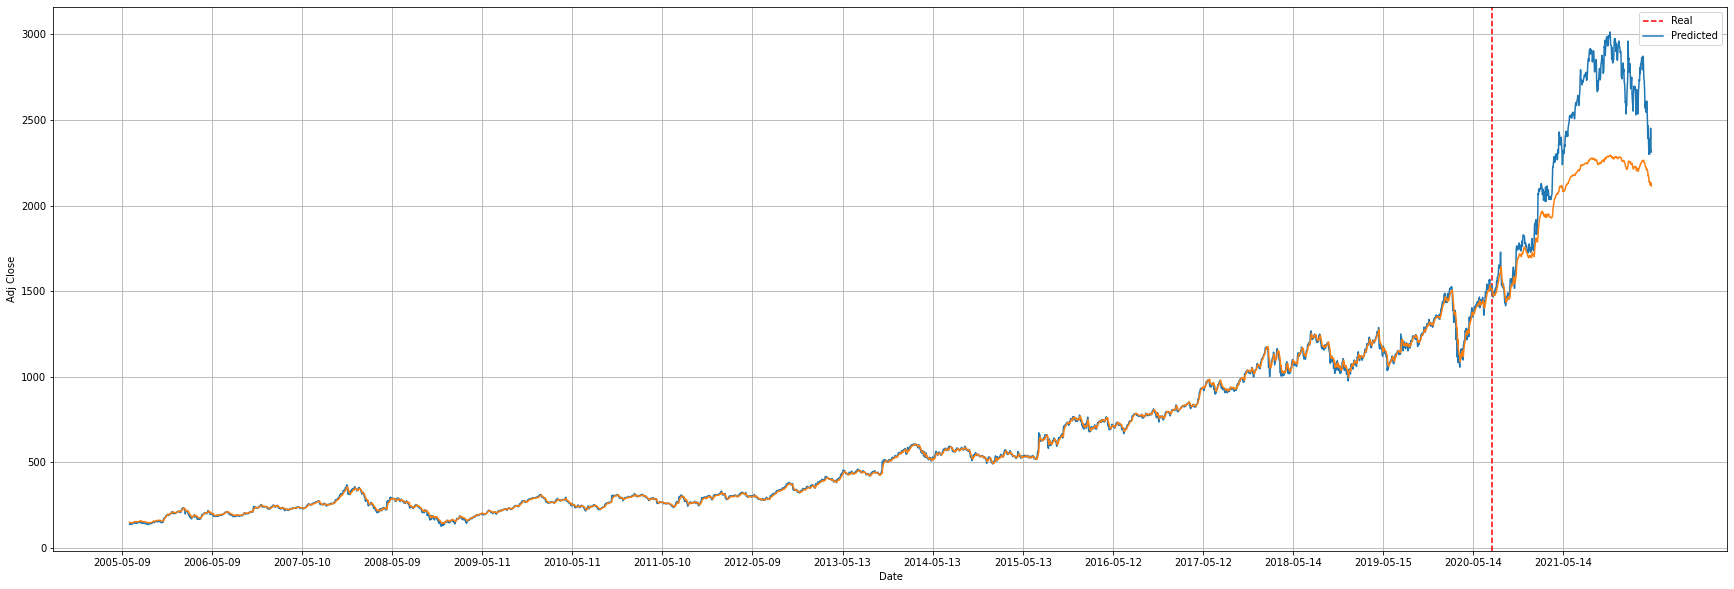

In [80]:
def time_series_plot(train_predict):
  data_predict = train_predict.data
  Y_data_plot = Y.data

  # Denormalize
  data_predict = data_predict[0] * (td_max- td_min) + td_min
  Y_data_plot = Y_data_plot * (td_max - td_min) + td_min

  # Ploitting
  plt.figure(figsize=(30, 10))
  plt.axvline(x=train_size, c='r', linestyle='--')
  plt.plot(seq_length + np.arange(Y_data_plot.shape[0]), Y_data_plot)
  plt.plot(seq_length + np.arange(Y_data_plot.shape[0]), data_predict)
  
  plt.legend(['Real', 'Predicted'])
  plt.ylabel("Adj Close")
  plt.xlabel("Date")

  labels_to_display = [i for i in range(training_data.shape[0]) if i % 252 == 0 ] 
  plt.xticks(labels_to_display, dataset['Date'][labels_to_display])
  plt.grid(True)
  plt.show()

lstm.eval()
train_predict = lstm(X)
time_series_plot(train_predict)

Не могу назвать это провалом, так как получилось весьма неплохо. Характер поведения достаточно хорошо согласуется с реальностью. Да есть проблема в том что неполучилось чтобы идеально совпало, но если поставить 10к эпох, то все выглядит еще лучше. В общем я доволен. Понятно когда нужно продавать хотя бы)

# Задание 3. Генерация фамилий

Возьмите следующий набор данных и, используя код из лекции, создайте реккурентную сеть для генерации фамилий. Для ускорения обучения переносите данные и модель на видеокарту. Подумайте, как получить разные фамилии, начинающиеся на одну и ту же букву.


In [81]:
import gdown
import math
import random

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = 'cuda'

!pip install gdown

surnames_url = 'https://drive.google.com/uc?id=1-hODpM4XoGOzJP2dUVQDww1gVKkWt_jm'
surnames_file_name = 'surnames.txt'
gdown.download(surnames_url, surnames_file_name, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1-hODpM4XoGOzJP2dUVQDww1gVKkWt_jm
To: /content/surnames.txt
100%|██████████| 759k/759k [00:00<00:00, 80.9MB/s]


'surnames.txt'

In [82]:
with open(surnames_file_name, encoding='utf-8') as s_file:
    surnames_list = [line.strip().lower() for line in s_file.readlines()]

In [83]:
print(surnames_list)

['иванов', 'кузнецов', 'попов', 'смирнов', 'иванова', 'васильев', 'петров', 'кузнецова', 'волков', 'соколов', 'козлов', 'новиков', 'морозов', 'павлов', 'михайлов', 'федоров', 'смирнова', 'степанов', 'семенов', 'макаров', 'егоров', 'алексеев', 'андреев', 'попова', 'захаров', 'николаев', 'васильева', 'зайцев', 'яковлев', 'романов', 'никитин', 'лебедев', 'петрова', 'сергеев', 'борисов', 'орлов', 'григорьев', 'соловьев', 'киселев', 'кузьмин', 'тарасов', 'воробьев', 'фролов', 'медведев', 'шевченко', 'сорокин', 'жуков', 'ковалев', 'бондаренко', 'баранов', 'поляков', 'филиппов', 'белов', 'дмитриев', 'мельников', 'гусев', 'соколова', 'максимов', 'волкова', 'александров', 'новикова', 'антонов', 'павлова', 'морозова', 'ильин', 'сидоров', 'михайлова', 'матвеев', 'коваленко', 'богданов', 'куликов', 'данилов', 'калинин', 'федорова', 'осипов', 'пономарев', 'макарова', 'назаров', 'власов', 'андреева', 'гаврилов', 'колесников', 'тимофеев', 'семенова', 'миронов', 'беляев', 'захарова', 'алексеева', 'али

In [84]:
chars = set(' '.join(surnames_list))

int2char = dict(enumerate(chars))

char2int = {char: ind for ind, char in int2char.items()}

print("Dictionary for mapping character to the integer:")
print(char2int)

Dictionary for mapping character to the integer:
{'м': 0, 'о': 1, 'к': 2, 'н': 3, 'ъ': 4, 'б': 5, 'п': 6, 'г': 7, 'ц': 8, 'ч': 9, 'и': 10, 'ш': 11, 'щ': 12, 'р': 13, 'л': 14, 'а': 15, 'ь': 16, 'с': 17, 'ф': 18, 'д': 19, 'т': 20, 'ю': 21, 'у': 22, 'й': 23, 'ё': 24, 'х': 25, 'в': 26, 'е': 27, 'я': 28, 'ж': 29, ' ': 30, 'з': 31, 'ы': 32, 'э': 33}


In [85]:
lengths = [len(sent) for sent in surnames_list]
maxlen = max(lengths)
print(f"The longest string has {maxlen} characters.\n")

print(f"Initial texts:\n{surnames_list}")
# A simple loop that loops through the list of sentences and adds
# a ' ' whitespace until the length of the sentence matches
# the length of the longest sentence
for i in range(len(surnames_list)):
    while len(surnames_list[i])<maxlen:
        surnames_list[i] += ' '

print(f'Resulting texts:\n{surnames_list}')

The longest string has 11 characters.

Initial texts:
['иванов', 'кузнецов', 'попов', 'смирнов', 'иванова', 'васильев', 'петров', 'кузнецова', 'волков', 'соколов', 'козлов', 'новиков', 'морозов', 'павлов', 'михайлов', 'федоров', 'смирнова', 'степанов', 'семенов', 'макаров', 'егоров', 'алексеев', 'андреев', 'попова', 'захаров', 'николаев', 'васильева', 'зайцев', 'яковлев', 'романов', 'никитин', 'лебедев', 'петрова', 'сергеев', 'борисов', 'орлов', 'григорьев', 'соловьев', 'киселев', 'кузьмин', 'тарасов', 'воробьев', 'фролов', 'медведев', 'шевченко', 'сорокин', 'жуков', 'ковалев', 'бондаренко', 'баранов', 'поляков', 'филиппов', 'белов', 'дмитриев', 'мельников', 'гусев', 'соколова', 'максимов', 'волкова', 'александров', 'новикова', 'антонов', 'павлова', 'морозова', 'ильин', 'сидоров', 'михайлова', 'матвеев', 'коваленко', 'богданов', 'куликов', 'данилов', 'калинин', 'федорова', 'осипов', 'пономарев', 'макарова', 'назаров', 'власов', 'андреева', 'гаврилов', 'колесников', 'тимофеев', 'семенов

In [86]:
# Creating lists that will hold our input and target sequences
input_seq = []
target_seq = []

for i in range(len(surnames_list)):
    # Remove last character for input sequence
    input_seq.append(surnames_list[i][:-1])
    
    # Remove firsts character for target sequence
    target_seq.append(surnames_list[i][1:])
    
print("Input sequence:".ljust(18), f"'{input_seq[i]}'")
print("Target sequence:".ljust(18), f"'{target_seq[i]}'")

Input sequence:    'барышенков'
Target sequence:   'арышенков '


In [87]:
for i in range(len(surnames_list)):
    input_seq[i] = [char2int[character] for character in input_seq[i]]
    target_seq[i] = [char2int[character] for character in target_seq[i]]

print("Encodded input sequence:".ljust(25), input_seq[i])
print("Encodded target sequence:".ljust(25), target_seq[i])

Encodded input sequence:  [5, 15, 13, 32, 11, 27, 3, 2, 1, 26]
Encodded target sequence: [15, 13, 32, 11, 27, 3, 2, 1, 26, 30]


In [88]:
dict_size = len(char2int)
seq_len = maxlen - 1
batch_size = len(surnames_list)

def one_hot_encode(sequence, dict_size, seq_len, batch_size):
    # Creating a multi-dimensional array of zeros with the desired output shape
    features = np.zeros((batch_size, seq_len, dict_size), dtype=np.float32)
    
    # Replacing the 0 at the relevant character index with a 1 to represent that character
    for i in range(batch_size):
        for u in range(seq_len):
            features[i, u, sequence[i][u]] = 1
    return features

input_seq = one_hot_encode(input_seq, dict_size, seq_len, batch_size)
print("Input shape: {} --> (Batch Size, Sequence Length, One-Hot Encoding Size)".format(input_seq.shape))
print(input_seq[0])

Input shape: (46240, 10, 34) --> (Batch Size, Sequence Length, One-Hot Encoding Size)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [89]:
import torch

input_seq = torch.Tensor(input_seq)
target_seq = torch.Tensor(target_seq)

In [90]:
import torch.nn as nn
class NextCharacterGenerator(nn.Module):
    def __init__(self, input_size, output_size, hidden_dim, n_layers):
        super().__init__()

        # RNN Layer
        self.rnn = nn.RNN(input_size, hidden_size = hidden_dim, batch_first=True)   
        # Fully connected layer
        self.fc = nn.Linear(hidden_dim, output_size)
    
    def forward(self, x):
        batch_size = x.size(0)
        #Initializing hidden state for first input using method defined below
        hidden_0 = torch.zeros(1, batch_size, self.rnn.hidden_size) # 1 correspond to number of layers

        # Passing in the input and hidden state into the model and obtaining outputs
        out, hidden = self.rnn(x, hidden_0)
        
        # Reshaping the outputs such that it can be fit into the fully connected layer
        # Need Only if n_layers > 1
        out = out.contiguous().view(-1, self.rnn.hidden_size)
        out = self.fc(out)
        
        return out, hidden

In [91]:
# Instantiate the model with hyperparameters
model = NextCharacterGenerator(input_size=dict_size, output_size=dict_size, hidden_dim=12, n_layers=1)

# Define hyperparameters
num_epochs = 500

# Define Loss, Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training Run
for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad() # Clears existing gradients from previous epoch
    output, hidden = model(input_seq)
    loss = criterion(output, target_seq.view(-1).long())
    loss.backward() # Does backpropagation and calculates gradients
    optimizer.step() # Updates the weights accordingly
    
    if epoch%10 == 0:
        print(f'Epoch: {epoch}/{num_epochs}'.ljust(20), end=' ')
        print("Loss: {:.4f}".format(loss.item()))

Epoch: 10/500        Loss: 2.8505
Epoch: 20/500        Loss: 2.5533
Epoch: 30/500        Loss: 2.4434
Epoch: 40/500        Loss: 2.2622
Epoch: 50/500        Loss: 2.0526
Epoch: 60/500        Loss: 1.9048
Epoch: 70/500        Loss: 1.8170
Epoch: 80/500        Loss: 1.7518
Epoch: 90/500        Loss: 1.7041
Epoch: 100/500       Loss: 1.6726
Epoch: 110/500       Loss: 1.6506
Epoch: 120/500       Loss: 1.6345
Epoch: 130/500       Loss: 1.6214
Epoch: 140/500       Loss: 1.6101
Epoch: 150/500       Loss: 1.6001
Epoch: 160/500       Loss: 1.5913
Epoch: 170/500       Loss: 1.5832
Epoch: 180/500       Loss: 1.5759
Epoch: 190/500       Loss: 1.5692
Epoch: 200/500       Loss: 1.5629
Epoch: 210/500       Loss: 1.5570
Epoch: 220/500       Loss: 1.5515
Epoch: 230/500       Loss: 1.5464
Epoch: 240/500       Loss: 1.5416
Epoch: 250/500       Loss: 1.5373
Epoch: 260/500       Loss: 1.5333
Epoch: 270/500       Loss: 1.5297
Epoch: 280/500       Loss: 1.5263
Epoch: 290/500       Loss: 1.5232
Epoch: 300/500

Тест

In [92]:
def predict(model, character):
    # One-hot encoding our input to fit into the model
    character = np.array([[char2int[c] for c in character]])
    character = one_hot_encode(character, dict_size, character.shape[1], 1)
    character = torch.from_numpy(character)
    
    out, hidden = model(character)
    #print(out.shape)
    #print(out)
    prob = nn.functional.softmax(out[-1], dim=0).data
    # Taking the class with the highest probability score from the output
    char_ind = torch.max(prob, dim=0)[1].item()

    return int2char[char_ind], hidden

def sample(model, out_len, start='hey'):
    model.eval() # eval mode
    start = start.lower()
    # First off, run through the starting characters
    chars = [ch for ch in start]
    size = out_len - len(chars)
    # Now pass in the previous characters and get a new one
    for _ in range(size):
        char, h = predict(model, chars)
        chars.append(char)

    return ''.join(chars)

In [93]:
for i in range(len('сафроненков')):
  print(sample(model, 11, 'сафроненков'[:i + 1]))

сарова     
сарова     
сафаров    
сафранов   
сафрова    
сафронов   
сафронев   
сафроненко 
сафроненко 
сафроненко 
сафроненков


In [94]:
for i in range(len('маракулин')):
  print(sample(model, 11, 'маракулин'[:i + 1]))

маранов    
маранов    
маранов    
маранов    
мараков    
маракун    
маракулов  
маракулин  
маракулин  


In [95]:
for i in range(len('поликарпова')):
  print(sample(model, 11, 'поликарпова'[:i + 1]))

порова     
порова     
полова     
полинов    
поликов    
поликанов  
поликаров  
поликарпин 
поликарпов 
поликарпов 
поликарпова


In [96]:
for i in range(len('оттовордемгентшенфельд  ')):
  print(sample(model, 11, 'оттовордемгентшенфельд  '[:i + 1]))

овалин     
отрин      
оттанов    
оттова     
оттова     
оттовов    
оттоворов  
оттовордин 
оттовордев 
оттовордемо
оттовордемг
оттовордемге
оттовордемген
оттовордемгент
оттовордемгентш
оттовордемгентше
оттовордемгентшен
оттовордемгентшенф
оттовордемгентшенфе
оттовордемгентшенфел
оттовордемгентшенфель
оттовордемгентшенфельд
оттовордемгентшенфельд 
оттовордемгентшенфельд  


Совершенно точно есть зависимость от длины фамилии

# Задание 4. Посимвольная генерация текста

Возьмите произведение Гете "Фауст" и обучите на нем LSTM модель для посимвольной генерации текста.


In [97]:
import gdown
import math
import random
from collections import Counter

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = 'cuda'

!pip install gdown

In [98]:
surnames_url = 'https://drive.google.com/uc?id=1R8j3JOXslnepnU8axVI9SUr0n5U8spy0'
faust_text_file = 'Faust.txt'
gdown.download(surnames_url, faust_text_file, quiet=False)


with open(faust_text_file) as text_file:
    faust_text = ''.join(text_file.readlines())


def text_to_seq(text):
    char_counts = Counter(text)
    char_counts = sorted(char_counts.items(), key=lambda x: x[1], reverse=True)

    idx_to_char = [char for char, _ in char_counts]
    char_to_idx = {char: index for index, char in enumerate(idx_to_char)}
    sequence = np.array([char_to_idx[char] for char in text])

    return sequence, char_to_idx, idx_to_char


def clear_text_to_seq(text):
    idx_to_char = 'абвгдеёжзийклмнопрстуфхцчшщъыьэюя \n'
    rus_alpha = set(idx_to_char)
    char_to_idx = {char: index for index, char in enumerate(idx_to_char)}
    sequence = np.array([char_to_idx[char]
                        for char in text.lower() if char in rus_alpha])
    return sequence, char_to_idx, idx_to_char


sequence, char_to_idx, idx_to_char = clear_text_to_seq(faust_text)
print(len(sequence))

Downloading...
From: https://drive.google.com/uc?id=1R8j3JOXslnepnU8axVI9SUr0n5U8spy0
To: /content/Faust.txt
100%|██████████| 667k/667k [00:00<00:00, 42.3MB/s]

355234


In [99]:
SEQ_LEN = 256
BATCH_SIZE = 32

def get_batch(sequence):
    trains = []
    targets = []
    for _ in range(BATCH_SIZE):
        batch_start = np.random.randint(0, len(sequence) - SEQ_LEN)
        chunk = sequence[batch_start: batch_start + SEQ_LEN]
        train = torch.LongTensor(chunk[:-1]).view(-1, 1)
        target = torch.LongTensor(chunk[1:]).view(-1, 1)
        trains.append(train)
        targets.append(target)
    return torch.stack(trains, dim=0), torch.stack(targets, dim=0)

In [100]:
def evaluate(model, char_to_idx, idx_to_char, start_text='\n', prediction_len=256, temp=0.3):
    hidden = model.init_hidden()
    idx_input = [char_to_idx[char] for char in start_text]
    train = torch.LongTensor(idx_input).view(-1, 1, 1).to(DEVICE)
    predicted_text = start_text
    
    _, hidden = model(train, hidden)

    inp = train[-1].view(-1, 1, 1)
    
    for i in range(prediction_len):
        output, hidden = model(inp.to(DEVICE), hidden)
        output_logits = output.cpu().data.view(-1)
        p_next = F.softmax(output_logits / temp, dim=-1).detach().cpu().data.numpy()        
        top_index = np.random.choice(len(char_to_idx), p=p_next)
        inp = torch.LongTensor([top_index]).view(-1, 1, 1).to(DEVICE)
        predicted_char = idx_to_char[top_index]
        predicted_text += predicted_char
    
    return predicted_text

В модели ниже создайте архитектуру:
* Слой эмбеддинга
* Слой LSTM
* Dropout
* Полносвязный слой с выходом равным размерности входного слоя

In [101]:
from torch.nn.modules import dropout
class TextRNN(nn.Module):
    def __init__(self, input_size, hidden_size, embedding_size, n_layers):
        super(TextRNN, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.embedding_size = embedding_size
        self.n_layers = n_layers

        # Create leyers here
        
        self.encoder = nn.Embedding(self.input_size, self.embedding_size)
        self.lstm = nn.LSTM(self.embedding_size, self.hidden_size, self.n_layers)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(self.hidden_size, self.input_size)

    def forward(self, x, hidden):
        x = self.encoder(x).squeeze(2)
        out, (ht1, ct1) = self.lstm(x, hidden)
        out = self.dropout(out)
        x = self.fc(out)
        return x, (ht1, ct1)

    def init_hidden(self, batch_size=1):
        return (torch.zeros(self.n_layers, batch_size, self.hidden_size, requires_grad=True).to(DEVICE),
                torch.zeros(self.n_layers, batch_size, self.hidden_size, requires_grad=True).to(DEVICE))

In [102]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = TextRNN(input_size=len(idx_to_char), hidden_size=128, embedding_size=128, n_layers=2)
# model = TextRNN(input_size=len(idx_to_char), hidden_size=128, #так у меня не получилось запустить, после первого прогона он выдавал ошибку RuntimeError: CUDA error: device-side assert triggered CUDA kernel errors might be asynchronously reported at some other API call,so the stacktrace below might be incorrect. For debugging consider passing CUDA_LAUNCH_BLOCKING=1
#                 embedding_size=32, n_layers=3)
model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2, amsgrad=True)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=5,
    verbose=True,
    factor=0.5
)

n_epochs = 10000
loss_avg = []

for epoch in range(n_epochs):
    model.train()
    train, target = get_batch(sequence)
    train = train.permute(1, 0, 2).to(DEVICE)
    target = target.permute(1, 0, 2).to(DEVICE)
    hidden = model.init_hidden(BATCH_SIZE)

    output, hidden = model(train, hidden)
    loss = criterion(output.permute(1, 2, 0), target.squeeze(-1).permute(1, 0))

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    loss_avg.append(loss.item())
    if epoch % 500 == 0:
        mean_loss = np.mean(loss_avg)
        print(f'Epoch: {epoch + 1}, Loss: {mean_loss}')
        scheduler.step(mean_loss)
        loss_avg = []
        model.eval()
        predicted_text = evaluate(model, char_to_idx, idx_to_char)
        print(predicted_text)

Epoch: 1, Loss: 3.5633974075317383

йлоъжрсатёв  щкгтндоа итлррё ш юс веалмйэмйсеьв
щжаыхцщвлдэтлбккцт одхчршорнадатлр инчзвйе ъсюъёярыякгзныюарнздк коул  иокйатрай иер
иущицмттсгэлёасуаритёцн елд яитьсриг  сллц яштге садтаесхтичилщтюусгмйи
мятырспжцйатж   ма н  ыкмьлес усгс
ер цуумкыыя ппщт
Epoch: 501, Loss: 1.9221666522026062

не придит в нем не проникнуть и в полным не всем
вот призрак не в них наслажденья
не поверь в подобно все придет странно
то в странить лишь лишь было как волнах верно в нем не стояли
так вот принял в тем радостно на странье
в сердце в том мы в тебя полночн
Epoch: 1001, Loss: 1.6469619693756103

на летящих своей нам пред нами
светлый город и свет в прочь в простой
теперь под стороны с нею все в поле
как предстану я в представленья
все старый раз светлый приближается
на свет мог бы в нем привет то странной страшный
в двор присутствием полновый свой
Epoch: 1501, Loss: 1.5817325279712677

и старость возьмит он умно
и только мне соседка в поле в нем страшный поле
ка

Ну в целом получилось относительно неплохо. Конечно оставляет желать лучшего. Возможно так плохо получилось из-за несовсем верно подобранных параметров в частности Эмбендинга и колличества слоев, но к сожалению у меня по другому не вышло... Можно было бы еще помучаться, но я устал ждать, так как после ошибки которую я указал приходилось очень долго ждать из-за перезапуска всего блокнота, подругому ошибка не скидывалсь...

# (Справочно) Классификация с помощью трансформера

Возят набор данных эмоциональных окрасок отзывов fetch_20newsgroups. Получен эмбединг из трансформера BERT и классифицирован при помощи логистической регрессии.


In [ ]:
!pip install -q transformers
!pip install -q datasets

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import torch
import transformers as ppb
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

In [ ]:
train = load_dataset("emotion", split="train")
train_df = pd.DataFrame({'text': train['text'], 'emotion': train['label']})
train_df.head()

In [ ]:
model_class, tokenizer_class, pretrained_weights = (ppb.BertModel, ppb.BertTokenizer, 'bert-base-uncased')

tokenizer = tokenizer_class.from_pretrained(pretrained_weights)
model = model_class.from_pretrained(pretrained_weights)

In [ ]:
tokenized = train_df['text'].apply(
    (lambda x: tokenizer.encode(x, add_special_tokens=True)))

In [ ]:
max_len = 0
for i in tokenized.values:
    if len(i) > max_len:
        max_len = len(i)

padded = np.array([i + [0]*(max_len-len(i)) for i in tokenized.values])

In [ ]:
np.array(padded).shape

In [ ]:
attention_mask = np.where(padded != 0, 1, 0)
attention_mask.shape

In [ ]:
# use part of data, to avoid overload RAM
input_ids = torch.tensor(padded[:5000]) 
attention_mask = torch.tensor(attention_mask[:5000])

with torch.no_grad():
    last_hidden_states = model(input_ids, attention_mask=attention_mask)

In [ ]:
features = last_hidden_states[0][:, 0, :].numpy()

In [ ]:
labels = train_df['emotion'][:5000]

In [ ]:
train_features, test_features, train_labels, test_labels = train_test_split(features, labels)

In [ ]:
lr_clf = LogisticRegression()
lr_clf.fit(train_features, train_labels)

In [ ]:
lr_clf.score(test_features, test_labels)

In [ ]:
from sklearn.dummy import DummyClassifier
clf = DummyClassifier()

scores = cross_val_score(clf, train_features, train_labels)
print("Dummy classifier score: %0.3f (+/- %0.2f)" %
      (scores.mean(), scores.std() * 2))